# Water tank temperature measurements analysis

In [91]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [106]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.thermal_utils import *
from usnm2p.fileops import *

### Inputs

In [107]:
dataroot = '/Users/tlemaire/Documents/data/US_thermal_experiments'
experiment = '20260904_tank'
datadir = os.path.join(dataroot, experiment)

# Root directory for output figures
figsdir = os.path.join(dataroot, 'figs')
if not os.path.exists(figsdir):
    os.makedirs(figsdir)
logger.info(f'output figures directory: "{figsdir}"')

# Figures dictionary
figs = {}

 2026/09/18 14:34:09: output figures directory: "/Users/tlemaire/Documents/data/US_thermal_experiments/figs"


### Load data

In [117]:
# Load and process the thermal experiment data
data = load_and_process_thermal_experiment(datadir, plot=True, figdict=figs)

# Compute ISPPA and ISPTA columns
data[Label.ISPPA] = pressure_to_intensity(data[Label.P] / PA_TO_MPA) / M2_TO_CM2  # W/cm2
data[Label.ISPTA] = data[Label.ISPPA] * data[Label.DC] / 1e2
for k in [Label.ISPPA, Label.ISPTA]:
    data[k] = data[k].round(2)

# Extract experimental duty cycle
DC = get_singleton(data, Label.DC)

logger.info('processed experiment data:')
data

 2026/09/18 14:42:20: loading processed data from "thermal_experiment_processed_datatank_T02_glass1layer_2.095MHz.h5"
 2026/09/18 14:42:21: processed experiment data:


T (°C)                  timestamp  x (mm)  y (mm)  z (mm)  \
trial time (s)                                                                  
0     -0.641675  26.761211 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.633325  26.763724 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.624975  26.762011 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.616625  26.759506 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.608275  26.761153 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
...                    ...                        ...     ...     ...     ...   
3023   3.090775  22.085236 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.099125  22.083559 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.107475  22.084416 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.115825  22.085895 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.124175  22.085344 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   

                 Fdrive (MHz)  P (MPa)   Vpp (V)  duration (s)  PRF (Hz)  \
trial time (s)                                                             
0     -0.641675         2.095      0.0  0.000000           0.2     100.0   
      -0.633325         2.095      0.0  0.000000           0.2     100.0   
      -0.624975         2.095      0.0  0.000000           0.2     100.0   
      -0.616625         2.095      0.0  0.000000           0.2     100.0   
      -0.608275         2.095      0.0  0.000000           0.2     100.0   
...                       ...      ...       ...           ...       ...   
3023   3.090775         2.095      0.8  0.257133           0.2     100.0   
       3.099125         2.095      0.8  0.257133           0.2     100.0   
       3.107475         2.095      0.8  0.257133           0.2     100.0   
       3.115825         2.095      0.8  0.257133           0.2     100.0   
       3.124175         2.095      0.8  0.257133           0.2     100.0   

                 DC (%)  elapsed time (s)  I_SPPA (W/cm2)  I_SPTA (W/cm2)  
trial time (s)                                                             
0     -0.641675    80.0          0.000000            0.00            0.00  
      -0.633325    80.0          0.000000            0.00            0.00  
      -0.624975    80.0          0.000000            0.00            0.00  
      -0.616625    80.0          0.000000            0.00            0.00  
      -0.608275    80.0          0.000000            0.00            0.00  
...                 ...               ...             ...             ...  
3023   3.090775    80.0      12522.377839           19.78           15.83  
       3.099125    80.0      12522.377839           19.78           15.83  
       3.107475    80.0      12522.377839           19.78           15.83  
       3.115825    80.0      12522.377839           19.78           15.83  
       3.124175    80.0      12522.377839           19.78           15.83  

[1366848 rows x 14 columns]

### Apply trial-by-trial linear detrending and compute evoked temperature change 

In [119]:
# Apply trial-by-trial linear detrending to the temperature data
gby = excluded(data.index, Label.TIME)
logger.info(f'detrending temperature traces for each {gby} combination')
data[f'detrended {Label.TEMP}'] = (
    data
    .groupby(gby)
    [Label.TEMP]
    .transform(detrend_trial)
)

# Compute trial-by-trial relative temperature change
logger.info('computing trial-by-trial relative temperature change')
data[Label.REL_TEMP] = (
    data
    .groupby(gby)
    [f'detrended {Label.TEMP}']
    .transform(compute_deltaT)
)

data

 2026/09/18 14:59:07: detrending temperature traces for each ['trial'] combination
 2026/09/18 14:59:13: computing trial-by-trial relative temperature change


T (°C)                  timestamp  x (mm)  y (mm)  z (mm)  \
trial time (s)                                                                  
0     -0.641675  26.761211 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.633325  26.763724 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.624975  26.762011 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.616625  26.759506 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.608275  26.761153 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
...                    ...                        ...     ...     ...     ...   
3023   3.090775  22.085236 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.099125  22.083559 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.107475  22.084416 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.115825  22.085895 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.124175  22.085344 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   

                 Fdrive (MHz)  P (MPa)   Vpp (V)  duration (s)  PRF (Hz)  \
trial time (s)                                                             
0     -0.641675         2.095      0.0  0.000000           0.2     100.0   
      -0.633325         2.095      0.0  0.000000           0.2     100.0   
      -0.624975         2.095      0.0  0.000000           0.2     100.0   
      -0.616625         2.095      0.0  0.000000           0.2     100.0   
      -0.608275         2.095      0.0  0.000000           0.2     100.0   
...                       ...      ...       ...           ...       ...   
3023   3.090775         2.095      0.8  0.257133           0.2     100.0   
       3.099125         2.095      0.8  0.257133           0.2     100.0   
       3.107475         2.095      0.8  0.257133           0.2     100.0   
       3.115825         2.095      0.8  0.257133           0.2     100.0   
       3.124175         2.095      0.8  0.257133           0.2     100.0   

                 DC (%)  elapsed time (s)  I_SPPA (W/cm2)  I_SPTA (W/cm2)  \
trial time (s)                                                              
0     -0.641675    80.0          0.000000            0.00            0.00   
      -0.633325    80.0          0.000000            0.00            0.00   
      -0.624975    80.0          0.000000            0.00            0.00   
      -0.616625    80.0          0.000000            0.00            0.00   
      -0.608275    80.0          0.000000            0.00            0.00   
...                 ...               ...             ...             ...   
3023   3.090775    80.0      12522.377839           19.78           15.83   
       3.099125    80.0      12522.377839           19.78           15.83   
       3.107475    80.0      12522.377839           19.78           15.83   
       3.115825    80.0      12522.377839           19.78           15.83   
       3.124175    80.0      12522.377839           19.78           15.83   

                 detrended T (°C)   ΔT (°C)  
trial time (s)                               
0     -0.641675         26.755289  0.003029  
      -0.633325         26.757858  0.005598  
      -0.624975         26.756202  0.003942  
      -0.616625         26.753754  0.001495  
      -0.608275         26.755458  0.003198  
...                           ...       ...  
3023   3.090775         22.087266 -0.001215  
       3.099125         22.085594 -0.002886  
       3.107475         22.086458 -0.002023  
       3.115825         22.087943 -0.000538  
       3.124175         22.087397 -0.001084  

[1366848 rows x 16 columns]

### Plot stim-evoked temperature traces across XYZ grid

 2026/09/18 15:00:35: plotting stimulus-evoked temperature traces for y = -0.5 mm
 2026/09/18 15:00:50: plotting stimulus-evoked temperature traces for y = 0.0 mm
 2026/09/18 15:01:00: plotting stimulus-evoked temperature traces for y = 0.5 mm


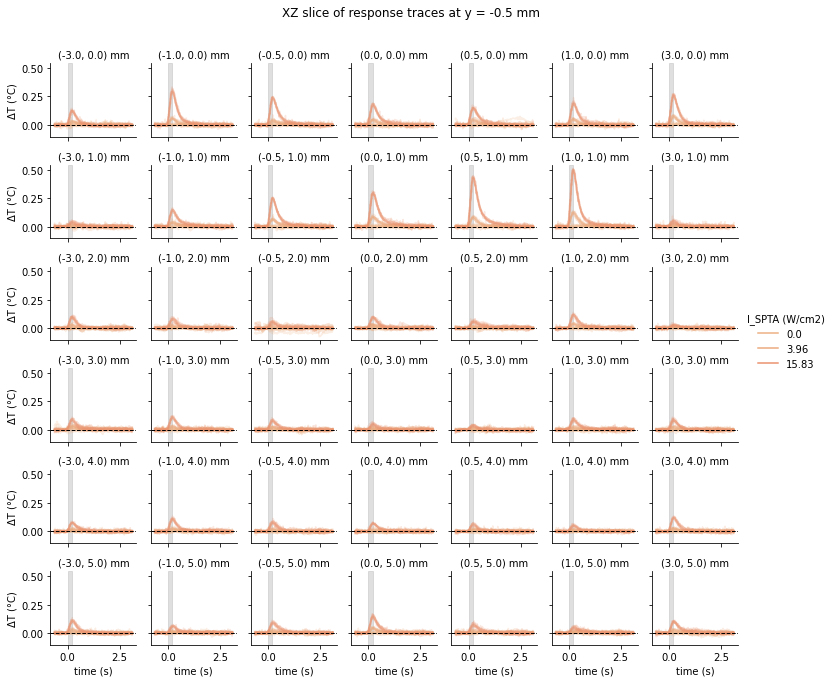

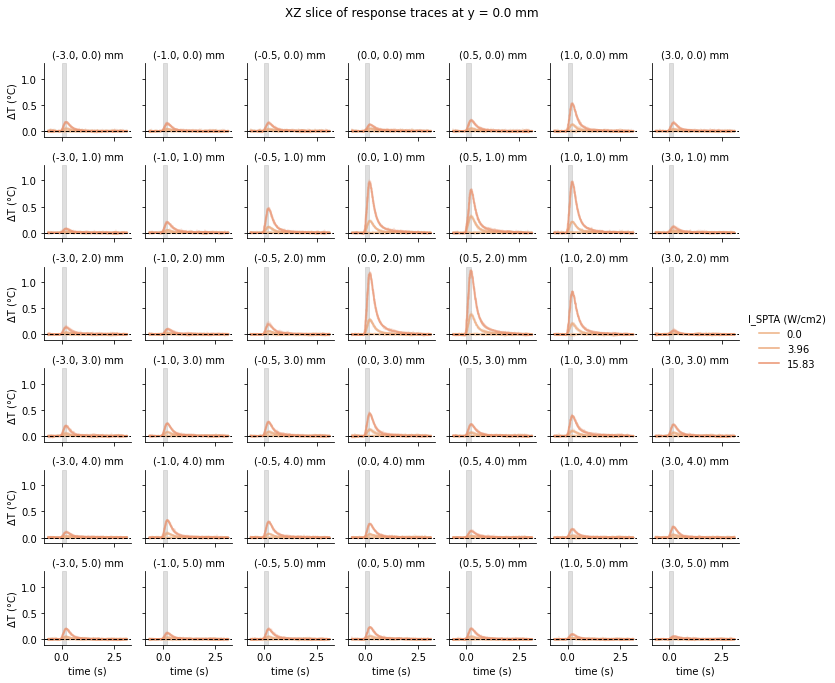

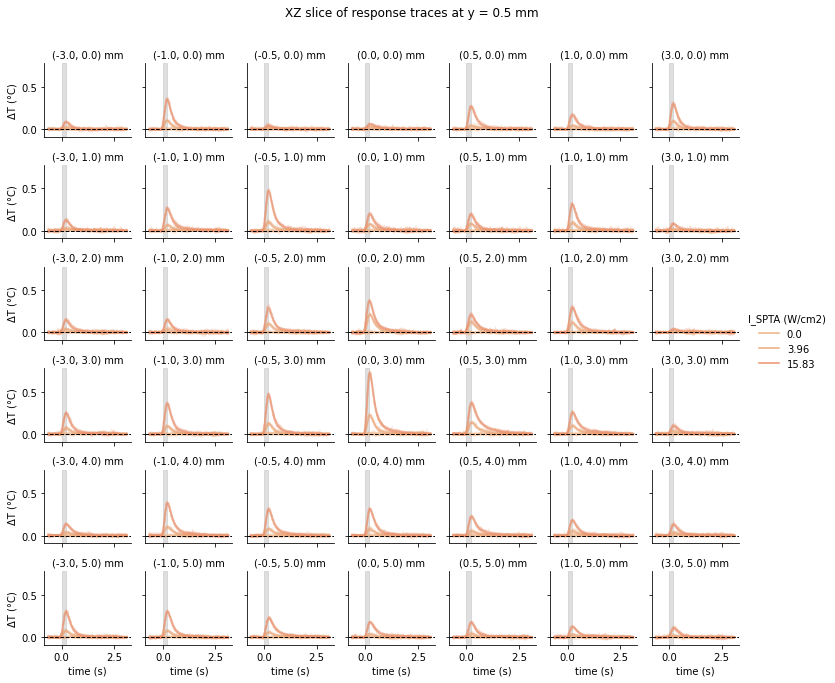

In [120]:
# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
for y, gdata in data.groupby(Label.Y_MM):
    logger.info(f'plotting stimulus-evoked temperature traces for y = {y:.1f} mm')
    figkey = f'XZ slice of response traces at y = {y:.1f} mm'
    g = sns.FacetGrid(
        data=gdata.reset_index(),
        col=Label.X_MM,
        row=Label.Z_MM,
        height=1.5,
    )
    g.set_titles(template='({col_name:.1f}, {row_name:.1f}) mm')
    g.map_dataframe(
        plot_evoked_thermal_response,
        y=Label.REL_TEMP, 
        estimator=None,
        units=Label.TRIAL,
        alpha=0.2,
        # errorbar='se',
        **TRACE_HUE_KWARGS,
    )
    g.add_legend(title=TRACE_HUE_KWARGS['hue'])
    figs[figkey] = g.figure
    figs[figkey].suptitle(figkey, y=1.05)

### Aggregate traces across trials for each condition 

In [121]:
# Aggregate traces across trials for each condition 
aggdata = compute_trial_average(data)
aggdata

 2026/09/18 15:01:55: computing trial-average data by ['x (mm)', 'y (mm)', 'z (mm)', 'P (MPa)', 'I_SPPA (W/cm2)', 'I_SPTA (W/cm2)']


T (°C)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)               
-3.0   -0.5   0.0    0.0     0.00           0.00           -0.641675  25.470824   
                                                           -0.633325  25.469734   
                                                           -0.624975  25.468912   
                                                           -0.616625  25.469246   
                                                           -0.608275  25.469799   
...                                                                         ...   
 3.0    0.5   5.0    0.8     19.78          15.83           3.090775  22.122608   
                                                            3.099125  22.122073   
                                                            3.107475  22.121733   
                                                            3.115825  22.123037   
                                                            3.124175  22.125579   

                                                                       Vpp (V)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)              
-3.0   -0.5   0.0    0.0     0.00           0.00           -0.641675  0.000000   
                                                           -0.633325  0.000000   
                                                           -0.624975  0.000000   
                                                           -0.616625  0.000000   
                                                           -0.608275  0.000000   
...                                                                        ...   
 3.0    0.5   5.0    0.8     19.78          15.83           3.090775  0.257133   
                                                            3.099125  0.257133   
                                                            3.107475  0.257133   
                                                            3.115825  0.257133   
                                                            3.124175  0.257133   

                                                                      detrended T (°C)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)                      
-3.0   -0.5   0.0    0.0     0.00           0.00           -0.641675         25.453770   
                                                           -0.633325         25.452843   
                                                           -0.624975         25.452185   
                                                           -0.616625         25.452682   
                                                           -0.608275         25.453399   
...                                                                                ...   
 3.0    0.5   5.0    0.8     19.78          15.83           3.090775         22.118937   
                                                            3.099125         22.118392   
                                                            3.107475         22.118041   
                                                            3.115825         22.119334   
                                                            3.124175         22.121865   

                                                                       ΔT (°C)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)              
-3.0   -0.5   0.0    0.0     0.00           0.00           -0.641675  0.000820   
                                                           -0.633325 -0.000106   
                                                           -0.624975 -0.000765   
                                                           -0.616625 -0.000267   
                                                           -0.608275  0.000449   
...                                                                        ...   
 3.0    0.5   5.0    0.8     19.78          15.83           3.090775 -0.003356   
                 

### Fit double exponential to trial-average profiles

 2026/09/18 15:05:02: fitting double exponential to trial-averaged temperature traces
 2026/09/18 15:05:07: constructing fitted double exponential traces
 2026/09/18 15:05:07: plotting t_0 (s) distribution
 2026/09/18 15:05:07: plotting peak (°C) distribution
 2026/09/18 15:05:07: plotting τ_rise (s) distribution
 2026/09/18 15:05:07: plotting τ_decay (s) distribution
 2026/09/18 15:05:07: plotting offset (°C) distribution


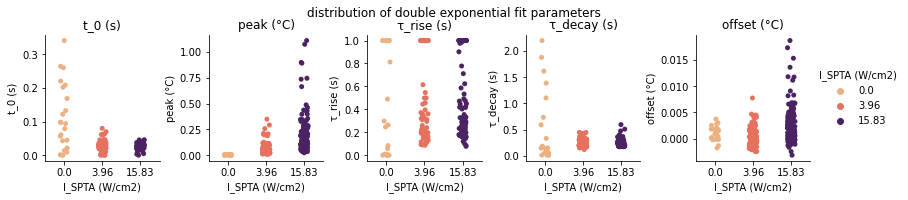

In [125]:
# Compute double exponential fits to the trial-averaged temperature traces
logger.info('fitting double exponential to trial-averaged temperature traces')
gby = excluded(aggdata.index, Label.TIME)
groups = aggdata.groupby(gby)[Label.REL_TEMP]
fits = groups.apply(fit_double_exp).unstack('parameter')

# Construct fitted double exponential traces
logger.info('constructing fitted double exponential traces')
aggdata[f'fitted {Label.REL_TEMP}'] = groups.apply(lambda x: pd.Series(
    double_exp_peak(
        x.index.get_level_values(Label.TIME).values,
        *fits.loc[x.name].values),
    index=x.index.get_level_values(Label.TIME))
)

naxes = len(fits.columns)
figkey = 'distribution of double exponential fit parameters'
figs[figkey], axes = plt.subplots(1, naxes, figsize=(2.5 * naxes, 2.5), constrained_layout=True)
for k, ax in zip(fits.columns, axes):
    logger.info(f'plotting {k} distribution')
    sns.stripplot(
        ax=ax,
        data=fits.reset_index(),
        x=TRACE_HUE_KWARGS['hue'],
        y=k,
        **TRACE_HUE_KWARGS,
        legend=ax is axes[-1],
    )
    ax.set_title(k)
    sns.despine(ax=ax)
sns.move_legend(axes[-1], 'center left', bbox_to_anchor=(1, 0.5), frameon=False)
figs[figkey].suptitle(figkey, y=1.05);

### Plot trial-averaged stim-evoked temperature traces and fitted double exponential traces

 2026/09/18 15:06:16: plotting trial-averaged stimulus-evoked temperature traces with fits for y = -0.5 mm
 2026/09/18 15:06:35: plotting trial-averaged stimulus-evoked temperature traces with fits for y = 0.0 mm
 2026/09/18 15:06:45: plotting trial-averaged stimulus-evoked temperature traces with fits for y = 0.5 mm


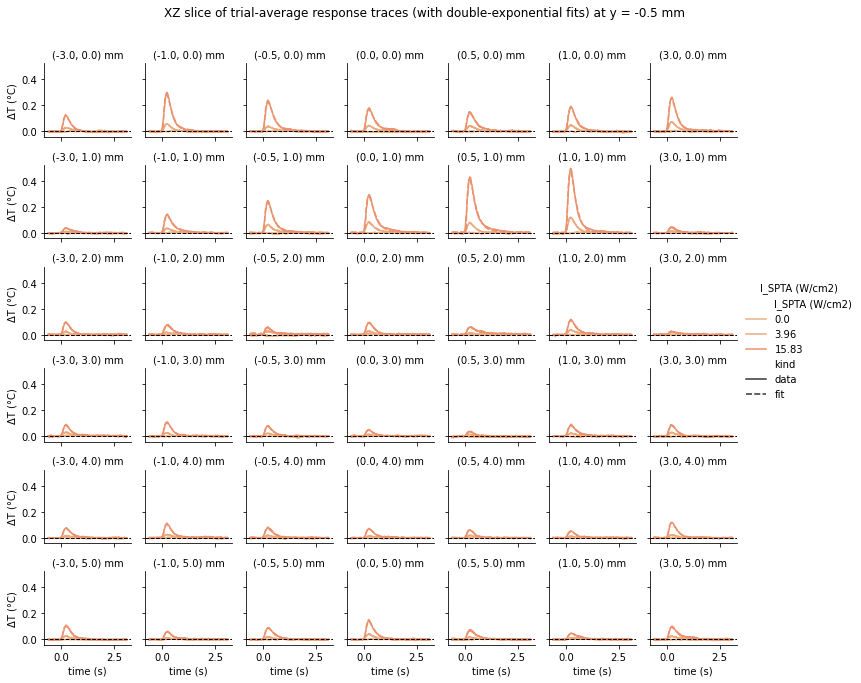

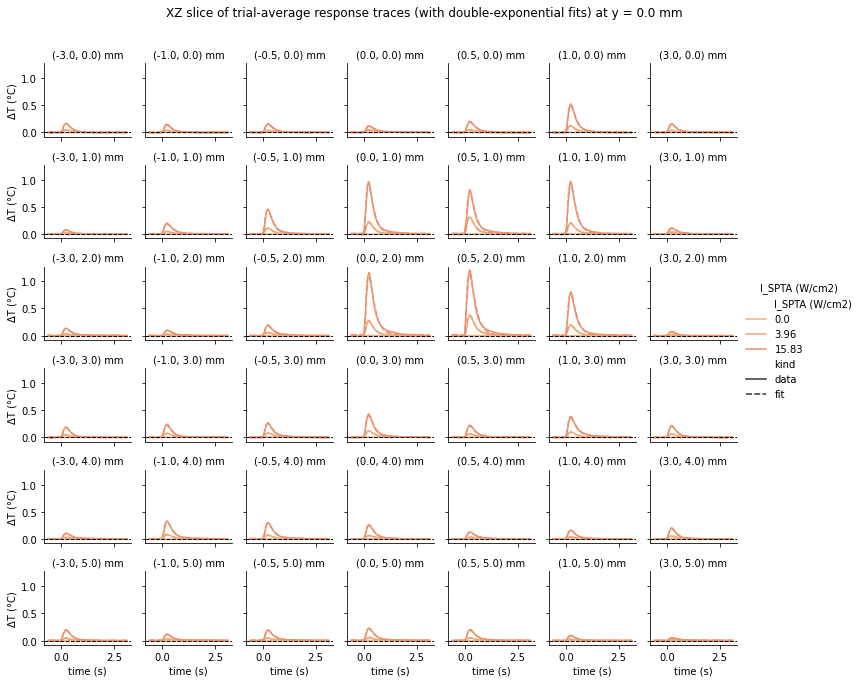

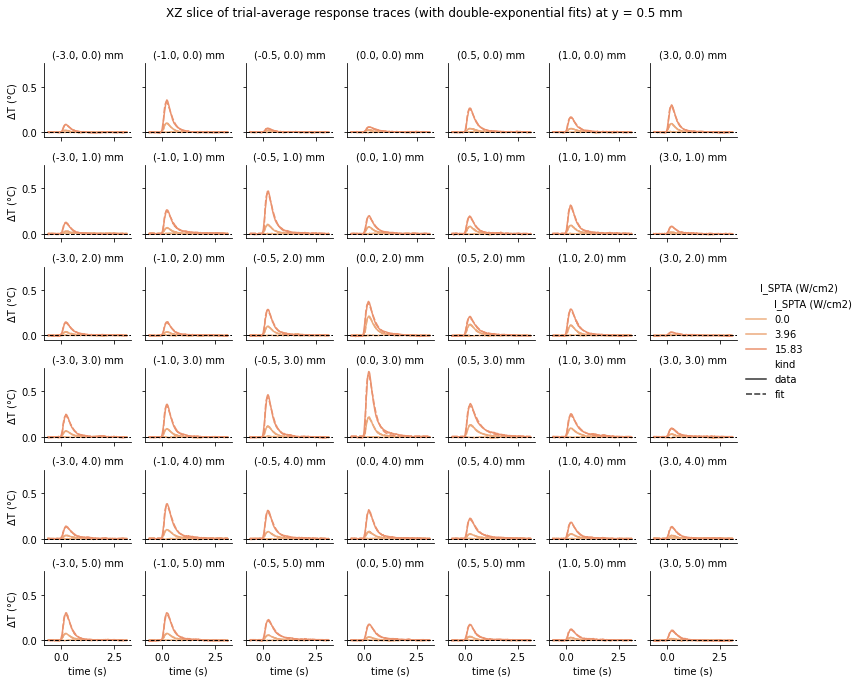

In [127]:
# Melt data by data/fit kind for plotting
ymap = {
    Label.REL_TEMP: 'data',
    f'fitted {Label.REL_TEMP}': 'fit'
}
melted_data = melt_by_condition(aggdata, ymap, 'kind')

# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure, with data and fitted traces distinguished by line style
for y, gdata in melted_data.groupby(Label.Y_MM):
    logger.info(f'plotting trial-averaged stimulus-evoked temperature traces with fits for y = {y:.1f} mm')
    figkey = f'XZ slice of trial-average response traces (with double-exponential fits) at y = {y:.1f} mm'
    g = sns.FacetGrid(
        data=gdata.reset_index(),
        col=Label.X_MM,
        row=Label.Z_MM,
        height=1.5,
    )
    g.set_titles(template='({col_name:.1f}, {row_name:.1f}) mm')
    g.map_dataframe(
        plot_evoked_thermal_response,
        y=Label.REL_TEMP, 
        style='kind',
        **TRACE_HUE_KWARGS
    )
    g.add_legend(title=TRACE_HUE_KWARGS['hue'])
    figs[figkey] = g.figure
    figs[figkey].suptitle(figkey, y=1.05)

### Compute and plot max-evoked temperature change for each location and pressure

In [154]:
from usnm2p.thermal_utils import plot_XZ_slice

 2026/09/18 15:36:19: computing max-evoked temperature change for each condition and trial
 2026/09/18 15:36:19: computing average max-evoked temperature change for each condition
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = -0.5 mm, I_SPTA (W/cm2) = 0.0
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = 0.0 mm, I_SPTA (W/cm2) = 0.0
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = 0.5 mm, I_SPTA (W/cm2) = 0.0
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = -0.5 mm, I_SPTA (W/cm2) = 3.96
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = 0.0 mm, I_SPTA (W/cm2) = 3.96
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = 0.5 mm, I_SPTA (W/cm2) = 3.96
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = -0.5 mm, I_SPTA (W/cm2) = 15.83
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = 0.0 mm, I_SPTA (W/cm2) = 15.83
 2026/09/18 15:36:19: plotting max ΔT (°C) XZ heatmap for y = 0.5 mm, I_SPTA (W/cm

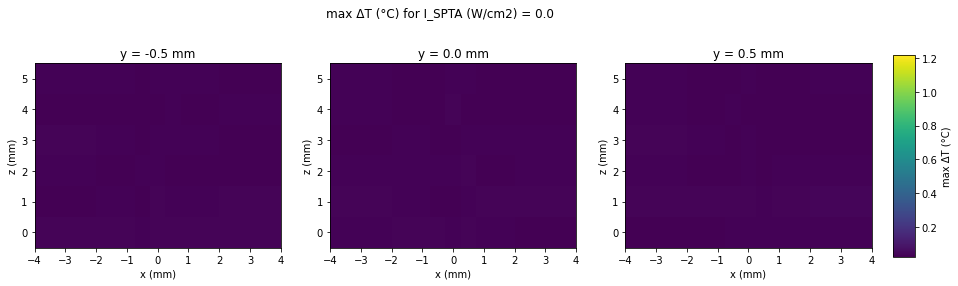

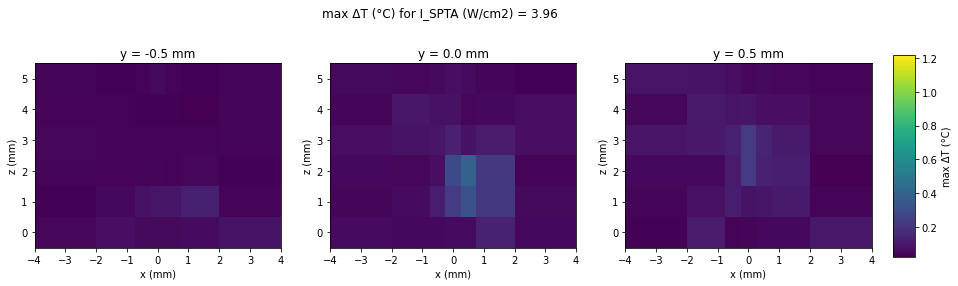

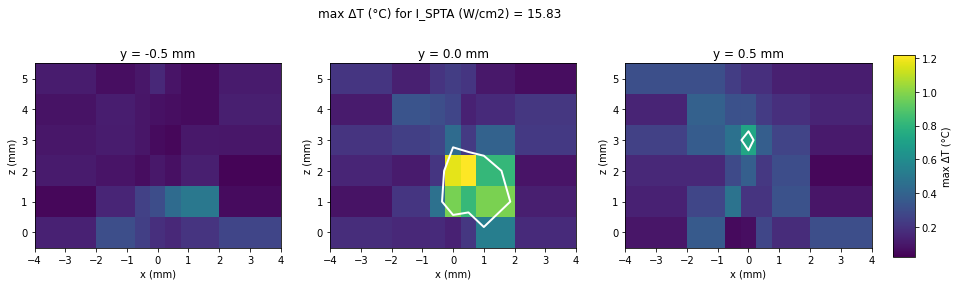

In [156]:
# Compute max-evoked temperature change for each condition and trial
cond_keys = condition_keys(data)
logger.info('computing max-evoked temperature change for each condition and trial')
max_evoked_change = (
    data
    .groupby([*cond_keys, 'trial'])
    [Label.REL_TEMP]
    .max()
    .rename(Label.MAX_REL_TEMP)
)
max_evoked_change

logger.info('computing average max-evoked temperature change for each condition')
agg_max_evoked_change = (
    max_evoked_change
    .groupby(cond_keys)
    .mean()
)

# Plot XZ heatmaps of max-evoked temperature change for each pressure and y position
vmin, vmax = agg_max_evoked_change.min(), agg_max_evoked_change.max()
dose_key = TRACE_HUE_KWARGS['hue']
gby = [Label.Y_MM, dose_key]
for dose, gdata in agg_max_evoked_change.groupby(dose_key):
    naxes = len(gdata.index.get_level_values(Label.Y_MM).unique())
    singledims = [k for k in gdata.index.names if len(gdata.index.get_level_values(k).unique()) == 1]
    figkey = f'{Label.MAX_REL_TEMP} for {dose_key} = {dose}'
    figs[figkey], axes = plt.subplots(1, naxes, figsize=(5 * naxes, 4), sharex=True)
    figs[figkey].suptitle(figkey, y=1.02)
    for (y, gdata2), ax in zip(gdata.droplevel(singledims).groupby(Label.Y_MM), axes):
        logger.info(f'plotting {Label.MAX_REL_TEMP} XZ heatmap for y = {y:.1f} mm, {dose_key} = {dose}')
        plot_XZ_slice(
            gdata2.droplevel(Label.Y_MM).unstack().T,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            vcontour=vmax / 2,
            title=f'y = {y:.1f} mm'
        )
        
    # Generate colorbar
    cbar_ax = figs[figkey].add_axes([0.92, 0.15, 0.02, 0.7])
    figs[figkey].colorbar(sm, cax=cbar_ax, label=Label.MAX_REL_TEMP)

### Plot ISPTA-dependence of evoked temperature change at focus

 2026/09/18 15:36:41: focus identified at XYZ = (0.5, 0.0, 2.0) mm, max ΔT (°C) = 1.22
 2026/09/18 15:36:41: plotting ISPTA-dependent evoked temperature change traces
 2026/09/18 15:36:42: performing least-square linear fit on max_ΔT vs ISPTA
 2026/09/18 15:36:42: least-square linear fit: slope = 0.078 °C/(W/cm²), R² = 0.99
 2026/09/18 15:36:42: plotting ISPTA-dependence of max-evoked temperature change at focus
 2026/09/18 15:36:42: predicted max-evoked temperature change at 15.83 W/cm²: 1.235 °C
 2026/09/18 15:36:43: max ΔT predicted at ISPTA = 15.83 W/cm2 at focus: 1.24 °C


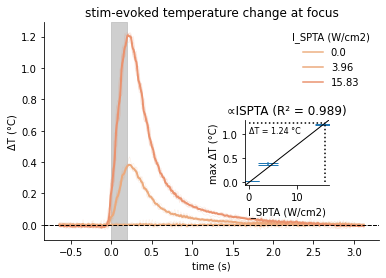

In [157]:
# Compute target ISPTA value corresponding to the reference pressure P_REF and experimental duty cycle DC
target_ISPPA = pressure_to_intensity(P_REF / PA_TO_MPA) / M2_TO_CM2  # W/cm2
target_ISPTA = np.round(target_ISPPA * DC / 1e2, 2)  # W/cm2

# Identify focus from trial-average max evoked temperature change at max pressure
maxP = data[Label.P].max()
focus_xyz = agg_max_evoked_change.loc[pd.IndexSlice[:, :, :, maxP]].idxmax()[:3]
focus_agg_max_evoked_change = agg_max_evoked_change.loc[
    pd.IndexSlice[focus_xyz[0], focus_xyz[1], focus_xyz[2], maxP, :, :]].values[0]
logger.info(f'focus identified at XYZ = {focus_xyz} mm, {Label.MAX_REL_TEMP} = {focus_agg_max_evoked_change:.2f}')

# Extract stats and data for the focus condition
focus_data, focus_max_evoked_change = select_subset(
    data, max_evoked_change, focus_xyz)

# Plot ISPTA dependence of temperature change at focus, with quadratic fit and R² value
figkey = 'stim-evoked temperature change at focus'
figs[figkey], max_ΔT_pred_at_target_ISPTA_at_focus = plot_ispta_dependence(
    focus_data, focus_max_evoked_change, title=figkey, Itarget=target_ISPTA)
logger.info(f'max ΔT predicted at ISPTA = {target_ISPTA:.2f} W/cm2 at focus: {max_ΔT_pred_at_target_ISPTA_at_focus:.2f} °C')

### Save figures

In [158]:
save_figs_book(figsdir, figs, suffix=experiment)

 2026/09/18 15:37:08: saving figures in /Users/tlemaire/Documents/data/US_thermal_experiments/figs/2026.09.18/figs_20260904_tank.pdf:


100%|██████████| 12/12 [00:29<00:00,  2.44s/it]
